Notebook to determine copy correction procedure from toy example. 

1. Start with toy example of fully synchronized reads. Show that we can transform from the equal total read count matrix to the copy number matrix.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Next test is seeing if the actual data copy numbers (normalized by samples) 
can be reconstructed to the copy number counts. It may not be possible, if we don't know the
total copy number count at each timepoint in the equal sample normalized data...

Is it the number of sites above 1? Or conversely, keep track of sites below 1 as remaining origins unreplicated. Either way there will be a period in which there is an approximately equal total sample of reads at the end of G1 and the start of G2M (end of S).


In [2]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis()
mnase_analysis_rep1.load_mnase_data(1, 10)


In [3]:
mnase_analysis_rep1.compute_sliding_window_counts_all_times()

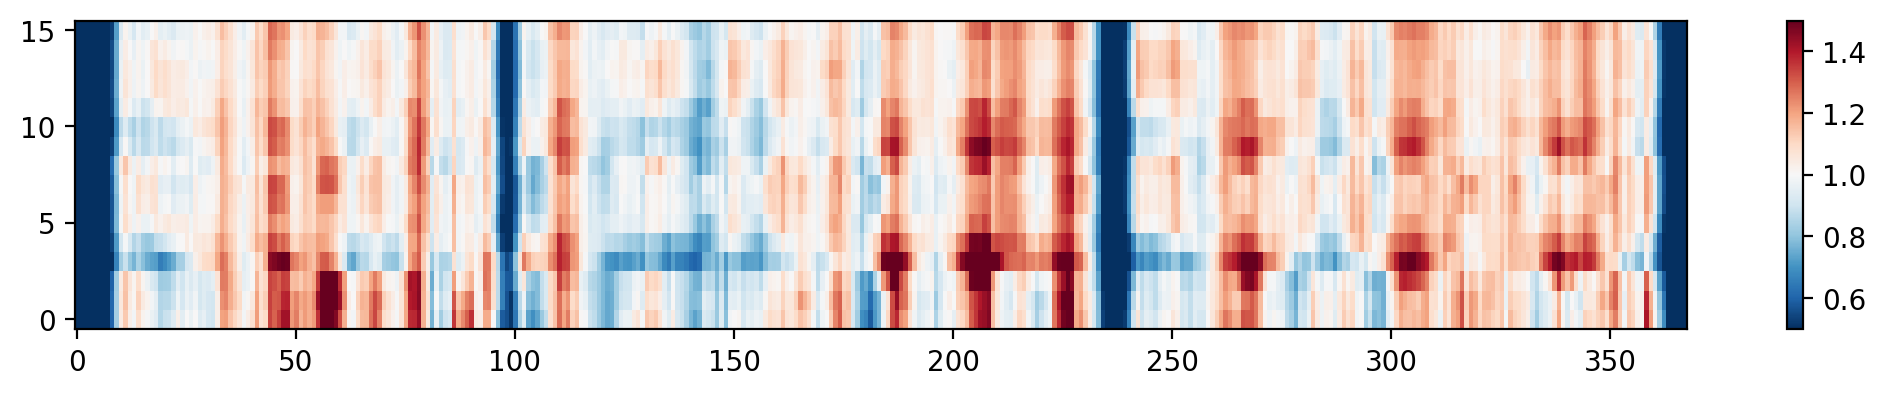

In [5]:
from src.helpers import normalize_sum_ndarray
from src.global_config import GlobalConstants

chrom10_reads_unnormalized = mnase_analysis_rep1.all_counts_unnormalized_df
normalized_chrom10_reads = normalize_sum_ndarray(chrom10_reads_unnormalized.T)

plt.figure(figsize=(13, 2))
plt.imshow(normalized_chrom10_reads, origin='lower',
          vmin=0.5, vmax=1.5, aspect='auto', cmap='RdBu_r')
plt.colorbar()
normalized_chrom10_reads.index = GlobalConstants.CHROM_WT1_TIMEPOINTS

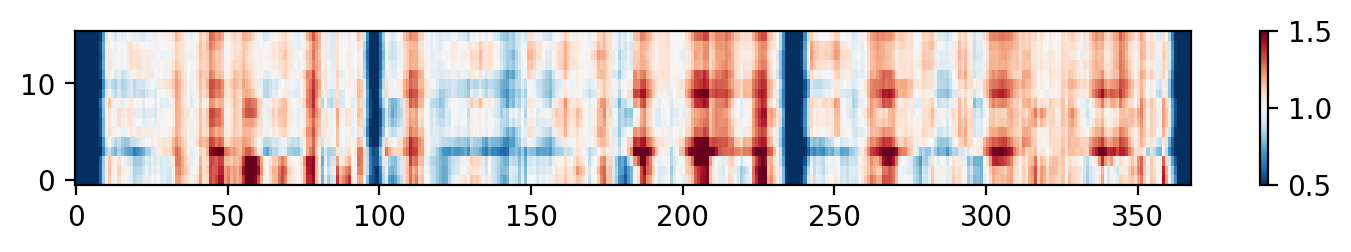

In [18]:
s_reads = normalized_chrom10_reads#.loc[[20, 30, 40, 50, 60, 70]]

# Select the timepoints for S
plt.figure(figsize=(9, 1))
plt.imshow(s_reads, origin='lower', interpolation='none',
          vmin=0.5, vmax=1.5, aspect='auto', cmap='RdBu_r')
plt.colorbar()

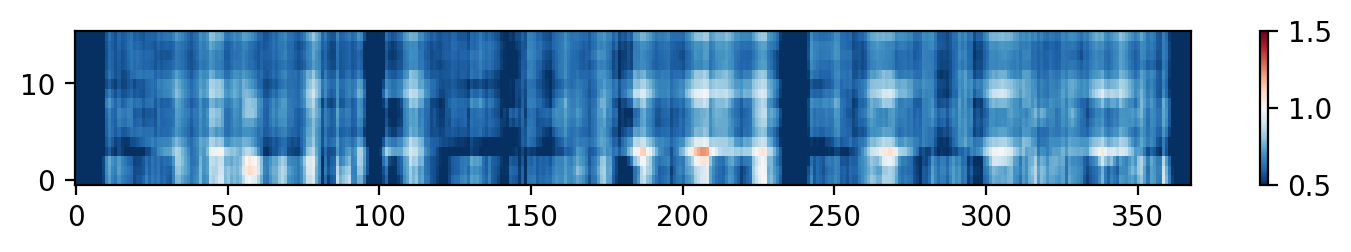

In [16]:
# We will be using the number of sites with an approximate read count greater than 1
# as indicative that the site has replicated
estimated_total_copy_number = ((s_reads > 1)+1).sum(axis=1)

# Using this estimated copy number, we can convert the read counts to estimated copy 
# number per site...
copy_number_estimation = s_reads * n / estimated_total_copy_number.values.reshape((-1, 1))

plt.figure(figsize=(9, 1))
plt.imshow(copy_number_estimation, origin='lower',
          vmin=0.5, vmax=1.5, aspect='auto', cmap='RdBu_r')
plt.colorbar()

# Getting closer, but we may need to start thinking about the variation in the cells
# at each timepoint next...

# Now here comes the question of how to incorpoate the H matrix, as a deconvolution step 
# or something else......
